## Employee Attrition Prediction Platform

### Model Training

\Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)

import shap
import os     
from datetime import datetime                        

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

\Loading the processed dataset

In [2]:
X_train = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\X_train.csv")
X_test  = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\X_test.csv")
y_train = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\y_train.csv").squeeze()
y_test  = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\y_test.csv").squeeze()

In [3]:
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)
print("\nTrain attrition %:", round(y_train.mean()*100, 2))
print("Test  attrition %:", round(y_test.mean()*100, 2))

X_train: (3063, 49) | y_train: (3063,)
X_test : (766, 49) | y_test : (766,)

Train attrition %: 16.29
Test  attrition %: 16.32


\baseline model

In [4]:
scale_pos_weight = (y_train ==0).sum() / (y_train == 1) .sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest" : RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "XGBoost" : XGBClassifier(scale_pos_weight=scale_pos_weight,random_state=42,eval_metric='logloss',n_jobs=-1)
}

print("\n5 baseline models defined ")
for name in models:
    print("  -", name)

scale_pos_weight for XGBoost: 5.14

5 baseline models defined 
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost


\Training five models and evaluating it

In [5]:
def evaluate(model, X_val, y_val, name):
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'F1': f1_score(y_val, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_val, y_proba)
    }

In [6]:
sample_weights = np.where(y_train ==1,scale_pos_weight,1)

results = []
fitted_models = {}

for name,model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train,y_train,sample_weight=sample_weights)
    else:
        model.fit(X_train,y_train)

    fitted_models[name]=model
    results.append(evaluate(model,X_test,y_test,name))
    print(f"{name:22s} trained ")

baseline_df = pd.DataFrame(results).set_index('Model')
print("\n" + "="*70)
print("BASELINE RESULTS — VALIDATION SET")
print("="*70)
print(baseline_df.to_string())

Logistic Regression    trained 
Decision Tree          trained 
Random Forest          trained 
Gradient Boosting      trained 
XGBoost                trained 

BASELINE RESULTS — VALIDATION SET
                     Accuracy  Precision  Recall        F1   ROC_AUC
Model                                                               
Logistic Regression  0.757180   0.378486   0.760  0.505319  0.832973
Decision Tree        0.975196   0.914062   0.936  0.924901  0.959420
Random Forest        0.979112   0.950413   0.920  0.934959  0.987232
Gradient Boosting    0.882507   0.594595   0.880  0.709677  0.944300
XGBoost              0.988251   0.975410   0.952  0.963563  0.986571


\ROC curve Visualization

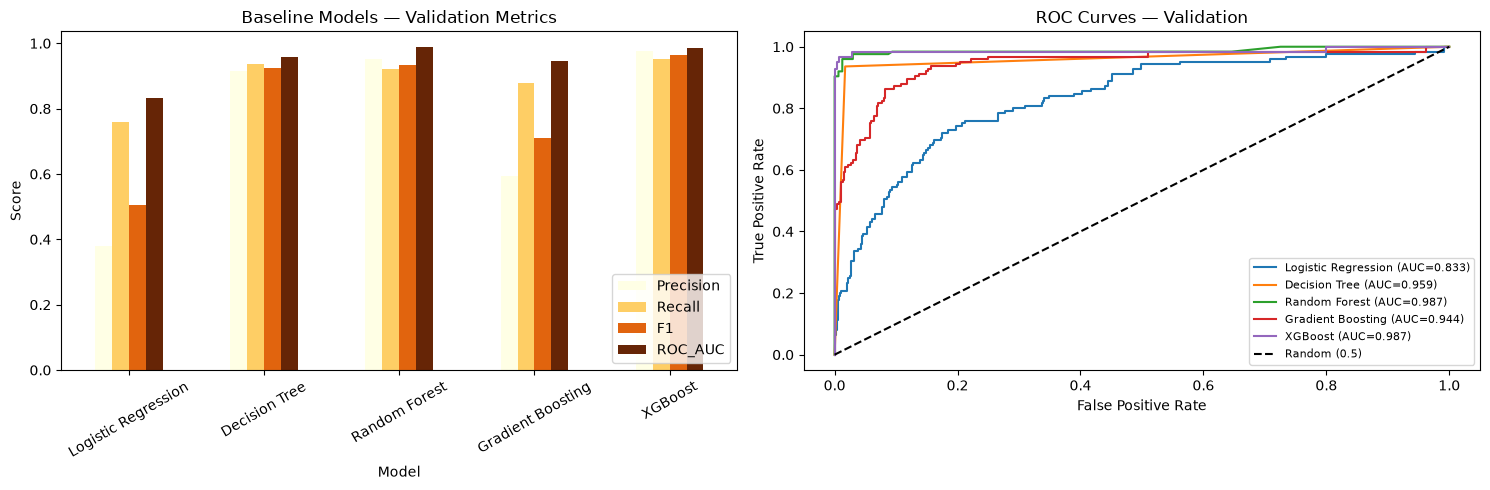

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Metrics comparison
baseline_df[['Precision','Recall','F1','ROC_AUC']].plot(
    kind='bar', ax=axes[0], colormap='YlOrBr')
axes[0].set_title('Baseline Models — Validation Metrics')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30)

# ROC curves
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1], [0,1], 'k--', label='Random (0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Validation')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\baseline_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

### Insights

-- XGBoost and Random Forest delivered the best overall performance, achieving the highest ROC-AUC (~0.99) along with strong Precision, Recall, and F1 scores.

-- Gradient Boosting also performed well, but its lower Recall and F1 score indicate that it missed more attrition cases than the top-performing models.

-- Logistic Regression showed the weakest performance, with lower Precision, F1 score, and ROC-AUC, making it less suitable for this prediction task.

-- The ROC curves show that XGBoost and Random Forest are closest to the top-left corner, indicating excellent class separation and better discrimination between employees who stay and those who leave.

\Selecting top 2 model for hyperparameter tuning

In [8]:
# Rank by F1 
ranked = baseline_df.sort_values('F1', ascending=False)

print("RANKING by F1 (Validation):")
print(ranked[['F1','Recall','Precision','ROC_AUC']].to_string())

top_2 = ranked.head(2).index.tolist()
print(f"\n TOP 2 selected for hyperparameter tuning:")
for i, m in enumerate(top_2, 1):
    print(f"  {i}. {m}  (F1={ranked.loc[m,'F1']}, ROC-AUC={ranked.loc[m,'ROC_AUC']})")

RANKING by F1 (Validation):
                           F1  Recall  Precision   ROC_AUC
Model                                                     
XGBoost              0.963563   0.952   0.975410  0.986571
Random Forest        0.934959   0.920   0.950413  0.987232
Decision Tree        0.924901   0.936   0.914062  0.959420
Gradient Boosting    0.709677   0.880   0.594595  0.944300
Logistic Regression  0.505319   0.760   0.378486  0.832973

 TOP 2 selected for hyperparameter tuning:
  1. XGBoost  (F1=0.9635627530364372, ROC-AUC=0.9865709828393137)
  2. Random Forest  (F1=0.9349593495934959, ROC-AUC=0.9872324492979719)


\Hyperparameter tuning

In [9]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

xgb_params = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 4, 5, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight,random_state=42,eval_metric ='logloss',n_jobs=-1)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_params,
    n_iter=30,             
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Tuning XGBoost")
xgb_search.fit(X_train, y_train)

print("\n XGBoost tuning done")
print("Best CV F1 :", round(xgb_search.best_score_, 4))
print("Best params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k:20s}: {v}")

Tuning XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 XGBoost tuning done
Best CV F1 : 0.9181
Best params:
  subsample           : 0.8
  n_estimators        : 200
  min_child_weight    : 3
  max_depth           : 8
  learning_rate       : 0.2
  colsample_bytree    : 0.9


In [10]:
rf_params = {
    'n_estimators':      [100, 200, 300, 400],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base, rf_params,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest")
rf_search.fit(X_train, y_train)

print("\n Random Forest tuning done")
print("Best CV F1 :", round(rf_search.best_score_, 4))
print("Best params:")
for k, v in rf_search.best_params_.items():
    print(f"  {k:20s}: {v}")


Tuning Random Forest
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Random Forest tuning done
Best CV F1 : 0.9161
Best params:
  n_estimators        : 400
  min_samples_split   : 2
  min_samples_leaf    : 1
  max_features        : log2
  max_depth           : 20


\re-evaluating the tuned model

In [11]:
tuned_results = []

xgb_best = xgb_search.best_estimator_
rf_best  = rf_search.best_estimator_

tuned_results.append(evaluate(xgb_best, X_test, y_test, "XGBoost (Tuned)"))
tuned_results.append(evaluate(rf_best, X_test, y_test, "Random Forest (Tuned)"))

tuned_df = pd.DataFrame(tuned_results).set_index('Model')

print("TUNED MODEL RESULTS — TEST SET")
print(tuned_df.to_string())

print("\nBASELINE vs TUNED (F1 score)")
for name in tuned_df.index:
    base_name = name.replace(" (Tuned)", "")
    base_f1 = baseline_df.loc[base_name, 'F1']
    tuned_f1 = tuned_df.loc[name, 'F1']
    diff = tuned_f1 - base_f1
    print(f"{name:28s} {base_f1:.4f} -> {tuned_f1:.4f}  ({diff:+.4f})")


TUNED MODEL RESULTS — TEST SET
                       Accuracy  Precision  Recall        F1   ROC_AUC
Model                                                                 
XGBoost (Tuned)        0.988251   1.000000   0.928  0.962656  0.984499
Random Forest (Tuned)  0.979112   0.965812   0.904  0.933884  0.989466

BASELINE vs TUNED (F1 score)
XGBoost (Tuned)              0.9636 -> 0.9627  (-0.0009)
Random Forest (Tuned)        0.9350 -> 0.9339  (-0.0011)


### Insights

-- The tuned XGBoost and Random Forest models achieved excellent performance on the test set, with XGBoost providing the highest F1 score (0.963) and Random Forest achieving the highest ROC-AUC (0.989).

-- Hyperparameter tuning resulted in performance that was nearly identical to the baseline models, indicating that the original models were already well-optimized.

In [12]:
# Complete comparison: all 5 baseline + 2 tuned
final_comparison = pd.concat([baseline_df, tuned_df])
final_comparison = final_comparison.sort_values('F1', ascending=False)

print("="*80)
print("MODEL COMPARISON REPORT — VALIDATION SET")
print("="*80)
final_comparison.to_csv(r"C:\NG\Employee Attrition Prediction\reports\model_comparison_report.csv")
print(final_comparison.to_string())


MODEL COMPARISON REPORT — VALIDATION SET
                       Accuracy  Precision  Recall        F1   ROC_AUC
Model                                                                 
XGBoost                0.988251   0.975410   0.952  0.963563  0.986571
XGBoost (Tuned)        0.988251   1.000000   0.928  0.962656  0.984499
Random Forest          0.979112   0.950413   0.920  0.934959  0.987232
Random Forest (Tuned)  0.979112   0.965812   0.904  0.933884  0.989466
Decision Tree          0.975196   0.914062   0.936  0.924901  0.959420
Gradient Boosting      0.882507   0.594595   0.880  0.709677  0.944300
Logistic Regression    0.757180   0.378486   0.760  0.505319  0.832973


\best model selection

In [13]:
best_model_name = final_comparison['F1'].idxmax()

model_lookup = {
    **fitted_models,
    'XGBoost (Tuned)': xgb_best,
    'Random Forest (Tuned)': rf_best
}

best_model = model_lookup[best_model_name]

print("="*70)
print(f"BEST MODEL SELECTED: {best_model_name}")
print("="*70)
print("\nMetrics (test set):")
print(final_comparison.loc[best_model_name].to_string())

print(f"\nModel type: {type(best_model).__name__}")
if hasattr(best_model, 'get_params'):
    print("\nKey hyperparameters:")
    params = best_model.get_params()
    for k in ['n_estimators','max_depth','learning_rate','subsample',
              'colsample_bytree','min_child_weight']:
        if k in params:
            print(f"  {k:20s}: {params[k]}")

BEST MODEL SELECTED: XGBoost

Metrics (test set):
Accuracy     0.988251
Precision    0.975410
Recall       0.952000
F1           0.963563
ROC_AUC      0.986571

Model type: XGBClassifier

Key hyperparameters:
  n_estimators        : None
  max_depth           : None
  learning_rate       : None
  subsample           : None
  colsample_bytree    : None
  min_child_weight    : None


\confusion matrix visual

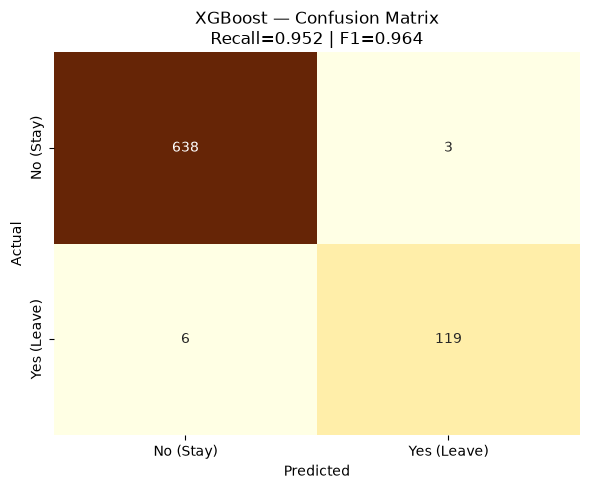

In [14]:
plt.figure(figsize=(6, 5))

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', cbar=False,
            xticklabels=['No (Stay)','Yes (Leave)'],
            yticklabels=['No (Stay)','Yes (Leave)'])
plt.title(f'{best_model_name} — Confusion Matrix\nRecall={recall_score(y_test,y_pred):.3f} | F1={f1_score(y_test,y_pred):.3f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\best_model_confusion_matrix.png", 
            dpi=100, bbox_inches='tight')
plt.show()

### Insights

-- The XGBoost model correctly predicted 638 employees who stayed and 119 employees who left, with only 9 misclassifications, showing excellent prediction performance.

-- The model achieved a Recall of 95.2% and an F1-score of 96.4%, indicating it is highly effective at identifying employees likely to leave while maintaining strong overall accuracy.

\shap analysis

SHAP computed  | shape: (766, 49)

TOP 10 FEATURES (SHAP):
                Feature  Mean_SHAP
         avg_work_hours   1.437078
                    Age   0.651617
EnvironmentSatisfaction   0.627510
        JobSatisfaction   0.540854
     NumCompaniesWorked   0.530227
          IncomePerYear   0.515063
   MaritalStatus_Single   0.498126
       ManagerStability   0.485012
      TotalWorkingYears   0.478486
            TenureRatio   0.461910


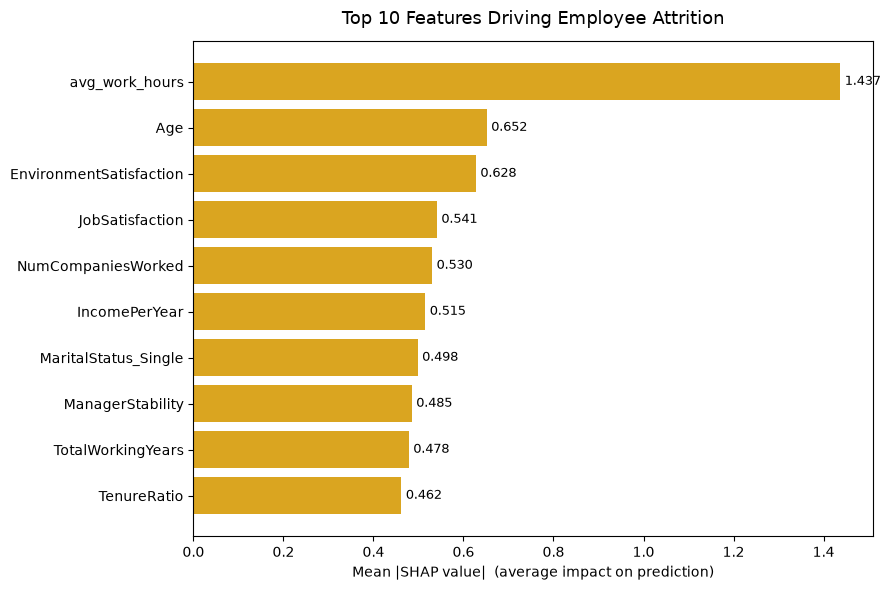

In [15]:
# SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("SHAP computed  | shape:", shap_values.shape)

importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

top10 = importance.head(10)

print("\nTOP 10 FEATURES (SHAP):")
print(top10.to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 6))
bars = plt.barh(top10['Feature'][::-1], top10['Mean_SHAP'][::-1], color='goldenrod')

for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.xlabel('Mean |SHAP value|  (average impact on prediction)')
plt.title('Top 10 Features Driving Employee Attrition', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\shap_top10_features.png",
            dpi=100, bbox_inches='tight')
plt.show()


### Insights

-- Average work hours is the most important factor influencing employee attrition, followed by age, environment satisfaction, and job satisfaction.

-- Employee experience, income, manager stability, and marital status also play a significant role, showing that both work conditions and personal factors affect the likelihood of employees leaving the company.

\Saving best model

In [16]:
model_bundle = {
    'model': best_model,
    'model_name': best_model_name,
    'feature_order': list(X_test.columns),                           
    'metrics': final_comparison.loc[best_model_name].to_dict(),
    'trained_on': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'n_features': X_test.shape[1]
}

joblib.dump(model_bundle, os.path.join(r"C:\NG\Employee Attrition Prediction\models", 'best_model.pkl'))

print(" Model saved: models/best_model.pkl")
print(f"\nModel      : {model_bundle['model_name']}")
print(f"Features   : {model_bundle['n_features']}")
print(f"Trained on : {model_bundle['trained_on']}")
print(f"\nMetrics:")
for k, v in model_bundle['metrics'].items():
    print(f"  {k:10s}: {v:.4f}")

 Model saved: models/best_model.pkl

Model      : XGBoost
Features   : 49
Trained on : 2026-07-20 18:41

Metrics:
  Accuracy  : 0.9883
  Precision : 0.9754
  Recall    : 0.9520
  F1        : 0.9636
  ROC_AUC   : 0.9866
